In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import linregress
from scipy import linalg
import networkx as nx # 用于生成复杂的异质拓扑
from scipy.stats import ortho_group
from scipy import stats

In [2]:
def init_matrix_with_controlled_spectrum(N, distribution='uniform', bounds=(0.1, 1.0), symmetric=True):
    """
    初始化权重矩阵 W，并强制其精度矩阵 A = WW^T 具有特定的谱分布和增强的非对角相关性。

    Args:
        N (int): 维度。
        distribution (str): 谱分布类型 ('uniform', 'power_law', 'bimodal')。
        bounds (tuple): 特征值范围 (min, max)。
        symmetric (bool): True=对称W, False=非对称W (Dale兼容)。
        align_mean_mode (bool): 
            - True (关键修改): 强制第一个特征向量指向 [1,1...1]。这会将 lambda[0] 的能量
              广播到整个矩阵的非对角元，使 A_ij 的量级不再趋于 0。
            - False: 纯随机旋转，A_ij 通常为 O(1/sqrt(N))，远小于 A_ii。

    Returns:
        W (ndarray): 权重矩阵。
        A (ndarray): 精度矩阵。
    """
    # --- 1. 生成 A 的特征向量基 Q (Output Basis) ---

    # 原始逻辑：纯随机基 (导致 A 接近对角阵)
    if N < 1000:
        Q = ortho_group.rvs(N)
    else:
        H = np.random.randn(N, N)
        Q, _ = linalg.qr(H)

    # --- 2. 定义 A 的目标谱 (Eigenvalues) ---
    if distribution == 'orthogonal':
        lambdas = np.ones(N) # A = I
    
    elif distribution == 'uniform':
        low, high = bounds
        lambdas = np.random.uniform(low, high, N)
        
    elif distribution == 'power_law':
        # 幂律分布 (Sloppy Model 常用)
        alpha = 1.0
        x = np.random.uniform(0, 1, N)
        lambdas = (1 - x) ** (-1/alpha)
        # 映射到 bounds
        l_min, l_max = lambdas.min(), lambdas.max()
        lambdas = bounds[0] + (lambdas - l_min) * (bounds[1] - bounds[0]) / (l_max - l_min)
        
    elif distribution == 'bimodal':
        # 双峰分布：模拟 E-I 分离的强相互作用
        # 一半很强(Stiff)，一半很弱(Sloppy)
        mid = N // 2
        lambdas = np.zeros(N)
        lambdas[:mid] = np.random.uniform(bounds[0], bounds[0]*10, mid) # Sloppy
        lambdas[mid:] = np.random.uniform(bounds[1]/10, bounds[1], N-mid) # Stiff
        
    else:
        raise ValueError("Unknown distribution")


    # --- 3. 重构 W (Reconstruction) ---
    # A = Q * diag(lambda) * Q.T
    
    sqrt_lam = np.sqrt(lambdas)
    
    if symmetric:
        # W 是对称平方根
        W = Q @ np.diag(sqrt_lam) @ Q.T
    else:
        # W 是混合符号 (Mixed Signs)
        # 使用独立的随机基 V 作为输入空间
        if N < 1000:
            V = ortho_group.rvs(N)
        else:
            H_v = np.random.randn(N, N)
            V, _ = linalg.qr(H_v)
            
        W = Q @ np.diag(sqrt_lam) @ V.T
    
    return W

In [3]:
class RobustHeterogeneousNetwork:
    def __init__(self, N, topology='scale_free', avg_degree=6, 
                 alpha=0.05, C=100.0, 
                 lambda_smooth=0.01, drop_prob=0.1):
        """
        Args:
            N (int): 神经元数量
            topology (str): 'small_world', 'scale_free', 'random'
            avg_degree (int): 平均连接度
            alpha (float): 熵正则化系数 (防止秩崩溃)
            C (float): 总能量约束 (Trace constraint)
            lambda_smooth (float): 拉普拉斯平滑强度 (强制空间连续性，降低IPR)
            drop_prob (float): DropConnect 概率 (引入噪声，强制鲁棒性)
        """
        self.N = N
        self.alpha = alpha
        self.C = C
        self.lambda_smooth = lambda_smooth
        self.drop_prob = drop_prob
        
        # 1. 构建异质拓扑结构 (Adjacency Mask)
        self.mask = self._generate_topology(topology, avg_degree)
        
        # 2. 预计算结构拉普拉斯矩阵 (Structural Laplacian)
        # 用于正则化：L = D - Adj
        # 这是基于物理连接的，不是基于功能权重的
        degree_matrix = np.diag(np.sum(self.mask, axis=1))
        self.L_struct = degree_matrix - self.mask
        
        # 3. 初始化权重 (Random Orthogonal-ish)
        # 使用较小的随机值，打破对称性
        w=init_matrix_with_controlled_spectrum(N, distribution='uniform', bounds=(0.9, 1))
        # w=np.random.randn(N, N) * 0.1
        w*=self.mask
        self.W = w
        
        current_energy = np.sum(w** 2) + 1e-12
        scale = np.sqrt(self.C / current_energy)
        w*= scale
        self.W_init=w
        
        A_init=w@ w.T + np.eye(self.N)*1e-6
        self.A_init=A_init
        self.A=A_init

    def _generate_topology(self, kind, avg_k):
        if kind == 'small_world':
            G = nx.watts_strogatz_graph(self.N, k=avg_k, p=0.2)
        elif kind == 'scale_free':
            m = max(1, avg_k // 2)
            G = nx.barabasi_albert_graph(self.N, m)
        else: # Random
            p = avg_k / self.N
            G = nx.erdos_renyi_graph(self.N, p)
            
        adj = nx.to_numpy_array(G)
        np.fill_diagonal(adj, 1.0) # Self-loops allowed
        return adj

    def normalize_W(self):
        """严格执行能量约束: Tr(WW^T) = C"""
        current_energy = np.sum(self.W ** 2) + 1e-12
        scale = np.sqrt(self.C / current_energy)
        self.W *= scale

    def get_effective_W(self, training=False):
        """
        获取当前权重。
        如果 training=True，应用 DropConnect (随机屏蔽连接)。
        """
        W_masked = self.W * self.mask
        
        if training and self.drop_prob > 0:
            # 生成二值 Drop 掩码 (1 = 保留, 0 = 丢弃)
            # 概率 (1-p) 保留
            drop_mask = (np.random.rand(*self.W.shape) > self.drop_prob).astype(float)
            
            # 缩放权重以保持期望值不变 (Inverted Dropout)
            # W_eff = W * mask / (1-p)
            scale = 1.0 / (1.0 - self.drop_prob)
            return W_masked * drop_mask * scale
        
        return W_masked

    def update_hebbian(self, v, lr,penalty_strength):
        """
        v: 输入信号在神经元上的投影 (Input projection)
        """
        # 1. 获取“带噪声”的权重视图 (DropConnect)
        # 这迫使网络不依赖特定的单一连接
        W_eff = self.get_effective_W(training=True)
        
        # 2. 计算当前精度矩阵 A (基于带噪声的权重)
        A = W_eff @ W_eff.T + np.eye(self.N)*1e-6
        self.A=A
        
        # 计算 A 的逆 (协方差)
        try:
            A_inv = np.linalg.inv(A)
        except np.linalg.LinAlgError:
            A_inv = np.linalg.pinv(A)

        # --- 梯度项计算 ---

        # A. Fisher Information Gradient (驱动力)
        # Term: v * v^T * W
        # 这一项让主要特征向量对齐信号方向
        grad_fisher = np.outer(v, v) @ W_eff
        
        # B. Entropy Regularization (最大熵/白化)
        # Term: alpha * A^-1 * W
        # 这一项防止所有特征值坍缩到同一个方向，保持秩
        grad_entropy = self.alpha * (A_inv @ W_eff)
        
        # C. Laplacian Regularization (空间平滑约束) - NEW
        # Loss = lambda * Tr(W^T L W) -> 邻居节点的权重应相似
        # Gradient = 2 * lambda * L @ W
        # 这强迫“软模式”在网络拓扑上是平滑变化的，直接对抗局域化(Localization)
        grad_smooth = self.lambda_smooth * (self.L_struct @ self.W)

        # D. Trace Constraint (能量约束拉格朗日乘子)
        # 动态计算 beta 以抵消增长
        v_proj = v.T @ A @ v
        # 粗略估计 beta，依靠后续 normalize_W 做精确修正
        beta = (v_proj + self.alpha * self.N) / self.C
        grad_trace = beta * W_eff


        
        
        # --- 组合梯度 ---
        # 注意：grad_smooth 是减去项（惩罚），grad_trace 也是减去项
        total_grad = 2 * (grad_fisher + grad_entropy - grad_trace) - grad_smooth
        
        # --- 更新 ---
        self.W += lr * total_grad
        
        # 强制拓扑约束 (Re-masking)
        self.W *= self.mask
        
        # 严格归一化 (防止数值漂移)
        self.normalize_W()

In [4]:
def get_gradients(N, mode='local'):
    x = np.linspace(0, 1, N)
    if mode == 'local':
        # 1. Localized: Only neurons near center care about s
        # return np.exp(-(x - 0.5)**2 / (2 * 0.05**2)).reshape(-1, 1)
        return np.sin(x * 0.5) * np.exp(-0.5 * (x / 15.0)**2) # High freq sensitivity
    
    elif mode == 'global_shift':
        # 2. Global: A wave-like gradient across all neurons
        return np.sin(2 * np.pi * x).reshape(-1, 1)
        # return np.exp(-0.5 * (x / 6.0)**2) # Low freq sensitivity
    
    elif mode == 'mean_field':
        # 3. Mean Field: All neurons care equally

        a=np.ones((N, 1))
        # a[:N//2]=-1
        return a#np.random.choice([1, -1], size=N)#np.ones((N, 1))
        # return np.linspace(0.9,1.0,N)

In [5]:
def calculate_xi_field_theory(A, N):
    """
    Corrected Ginzburg-Landau correlation length calculation.
    xi = sqrt(kappa / m^2)
    """
    # 1. Get eigenvalues and eigenvectors
    # We use eigh because A is symmetric
    vals, vecs = np.linalg.eigh(A)
    
    # Sort them just in case (eigh usually returns sorted)
    idx = np.argsort(vals)
    vals = vals[idx]
    vecs = vecs[:, idx]
    
    # 2. Identify the 'Mass' (Soft Mode eigenvalue)
    # This is the precision gap. If A is singular, m2 -> 0
    m2 = vals[0]
    
    # 4. Compute Correlation Length
    # Use a small epsilon to avoid division by zero at the critical point
    epsilon = 1e-12
    xi = np.sqrt(1 / (m2 + epsilon))
    
    # 5. Finite Size Clipping
    # Physical xi cannot meaningfully exceed the system size N
    return min(xi, N)

In [6]:
result_dir='result/'
modes=['local','global_shift','mean_field']
N_arr=np.array([100,200,300,400,500,600])
C = 2e2
H_weight=1e-3
topo='random'

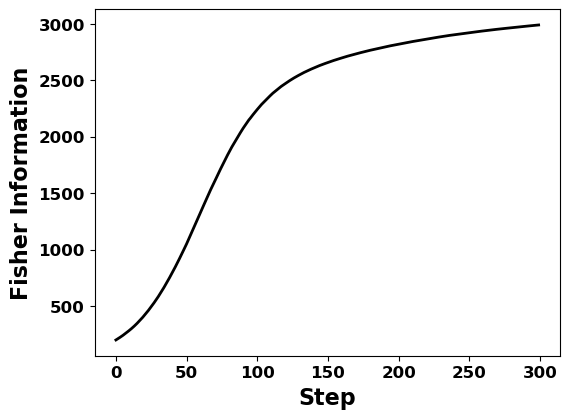

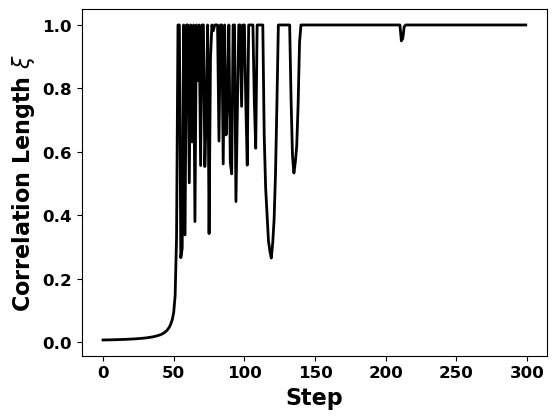

200.00009999999898 200.00009999999793


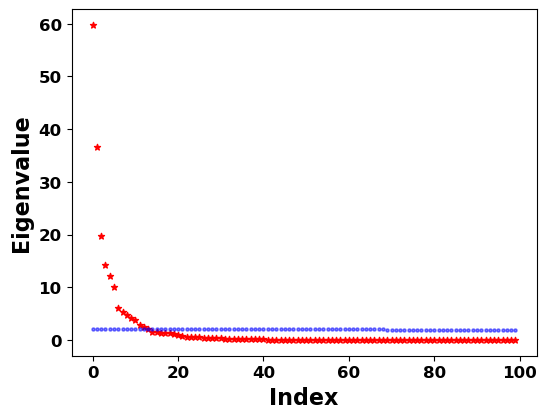

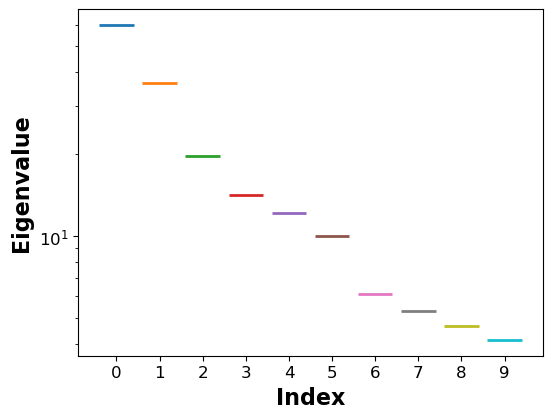

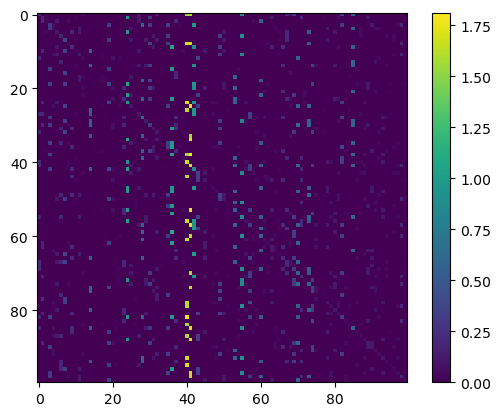

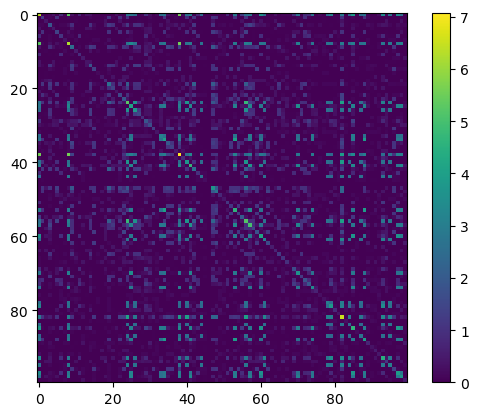

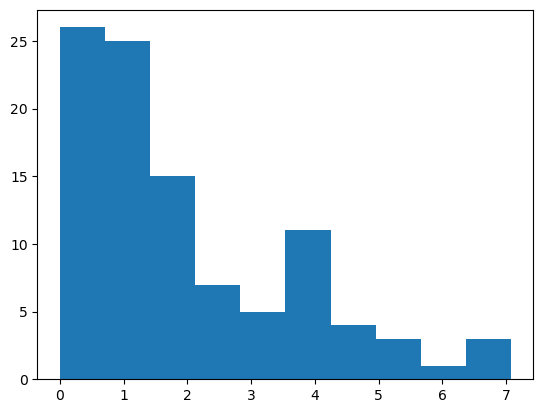

200.000099999999


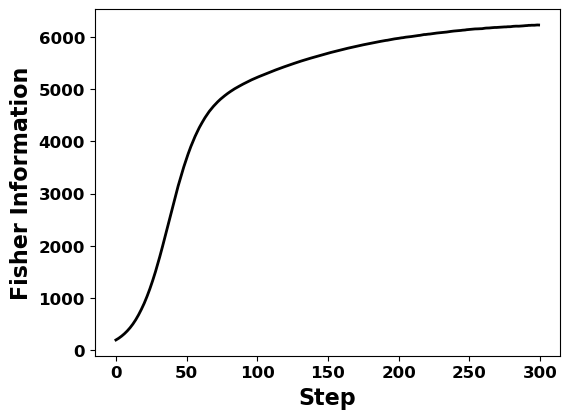

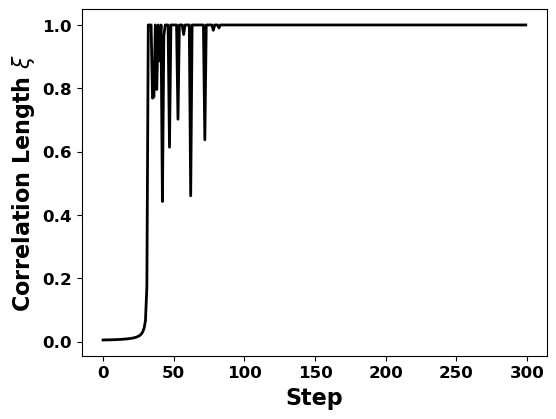

200.00019999999896 200.00019999999896


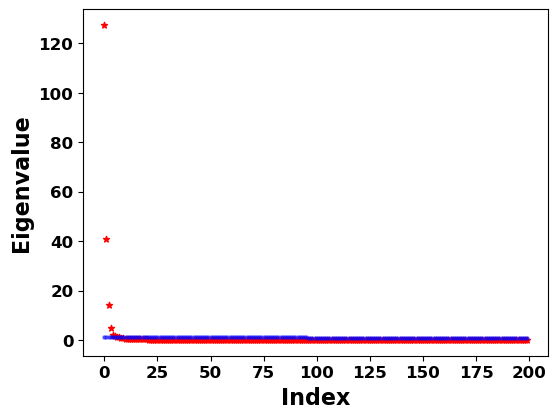

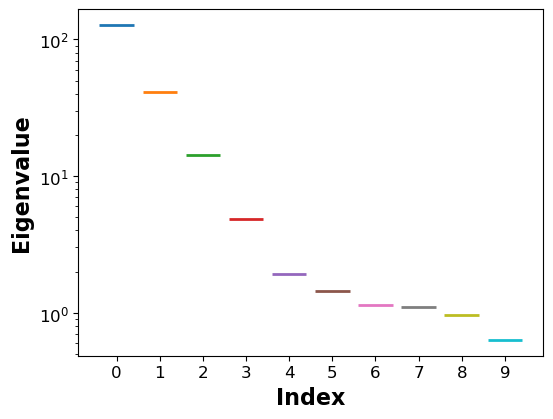

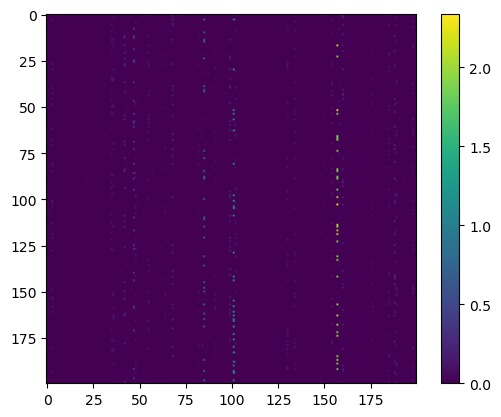

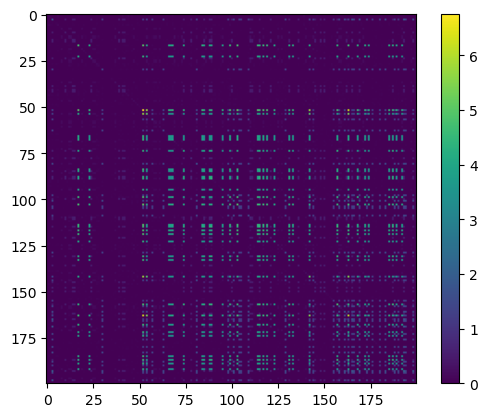

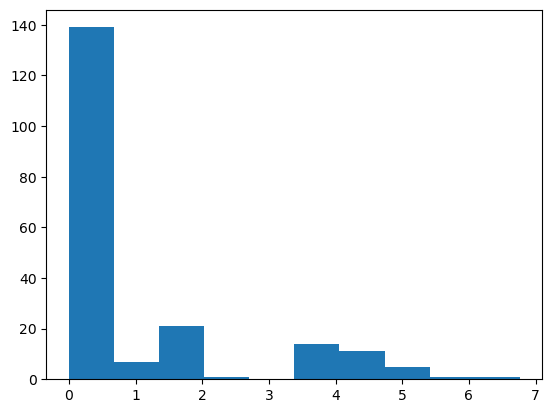

200.00019999999898


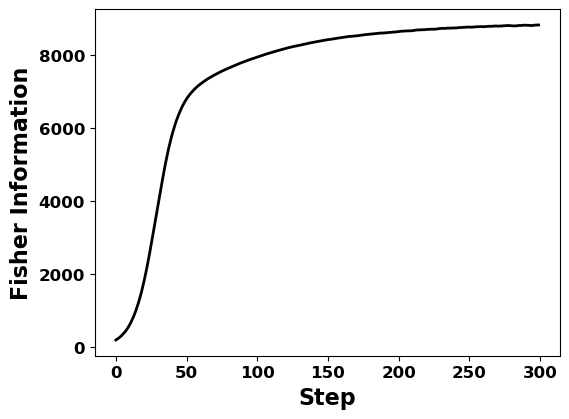

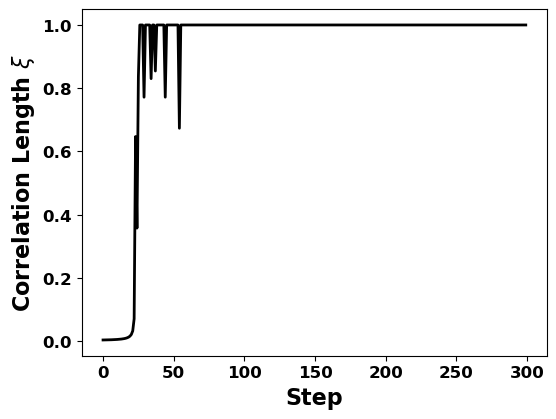

200.00029999999902 200.00029999999933


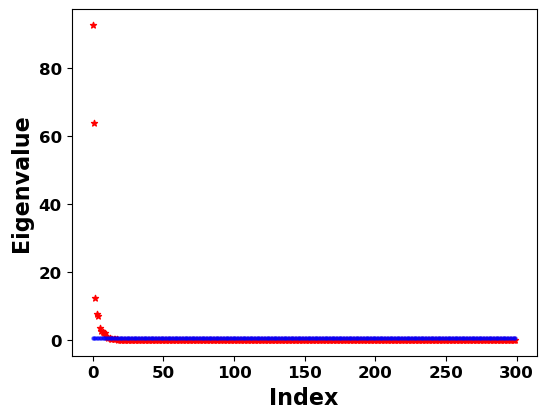

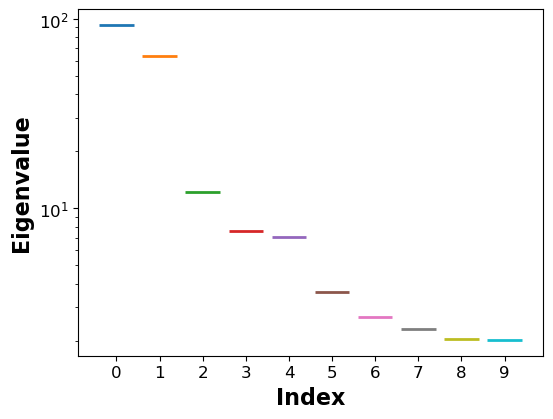

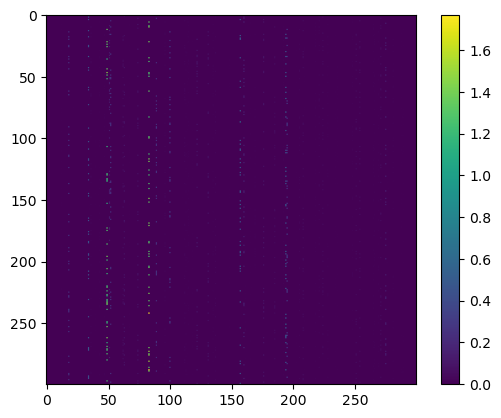

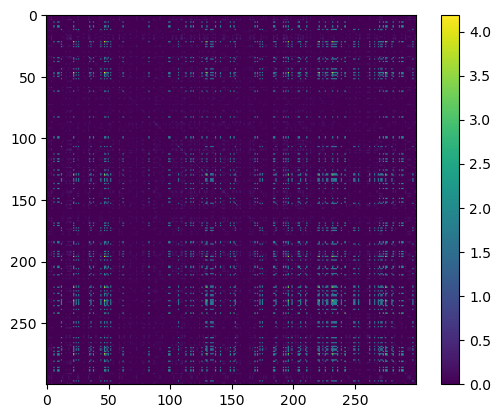

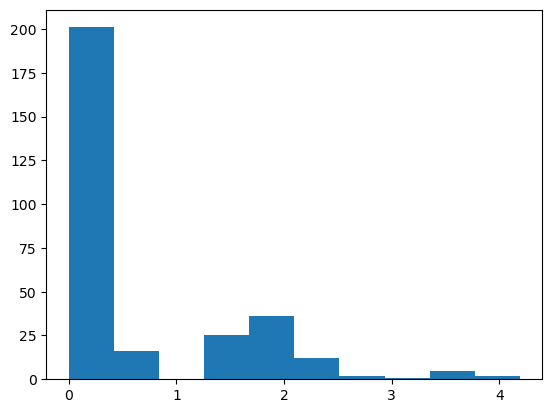

200.00029999999902


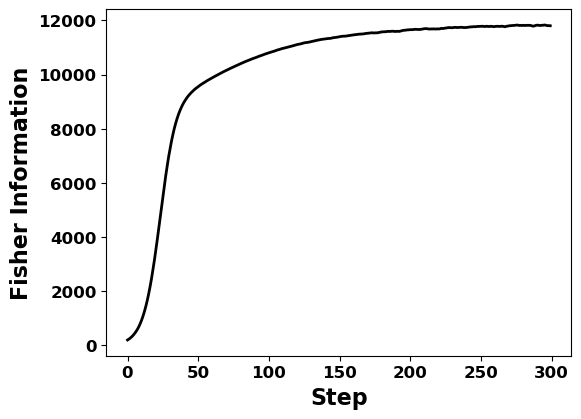

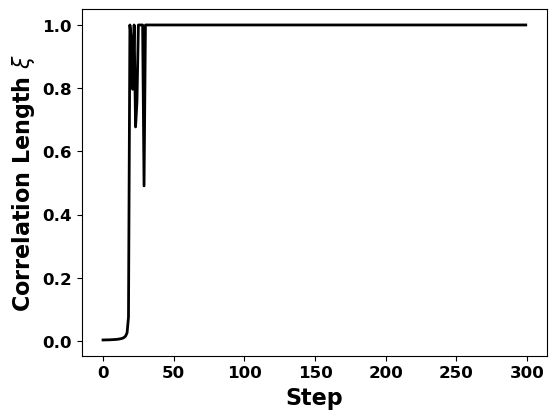

200.00039999999896 200.00039999999944


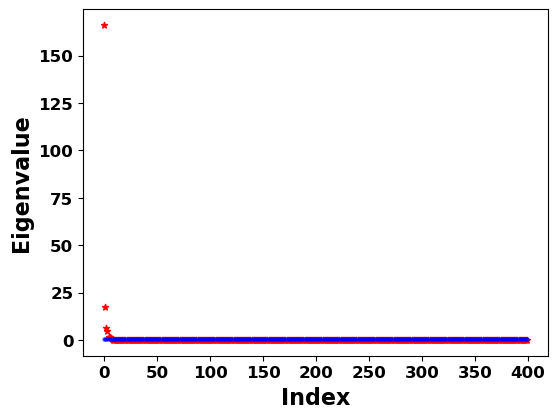

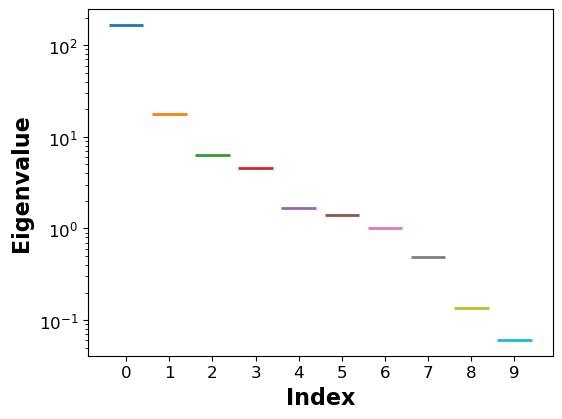

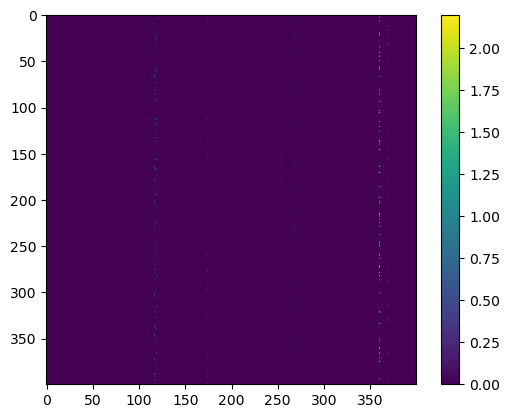

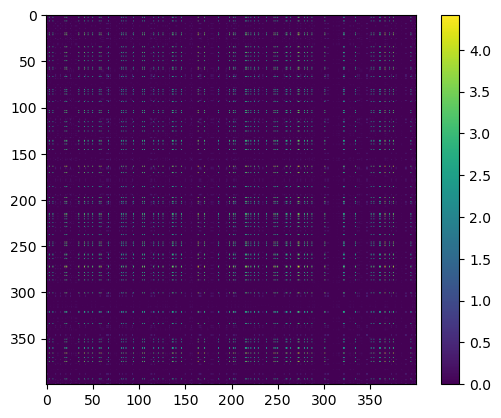

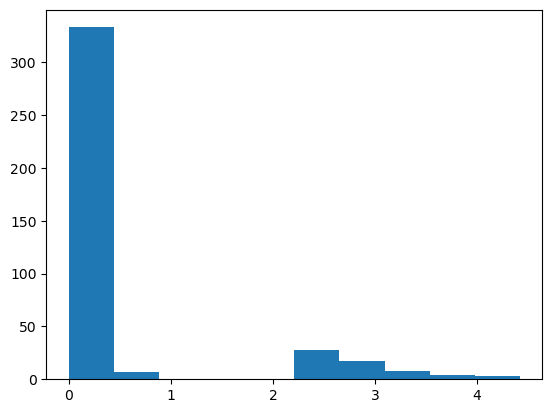

200.00039999999902


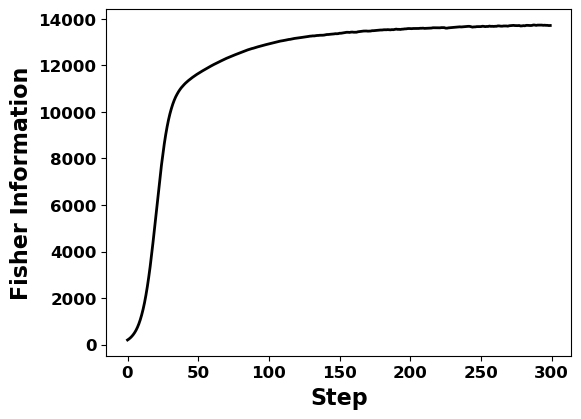

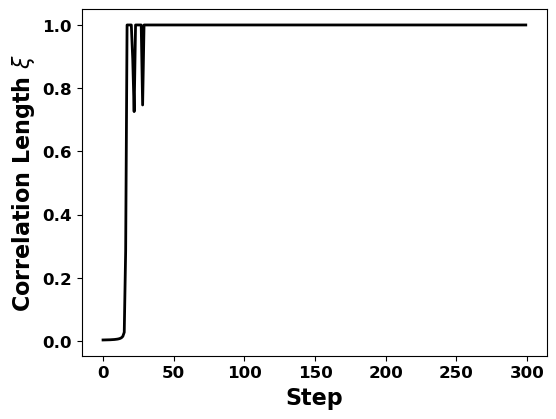

200.00049999999908 200.0004999999996


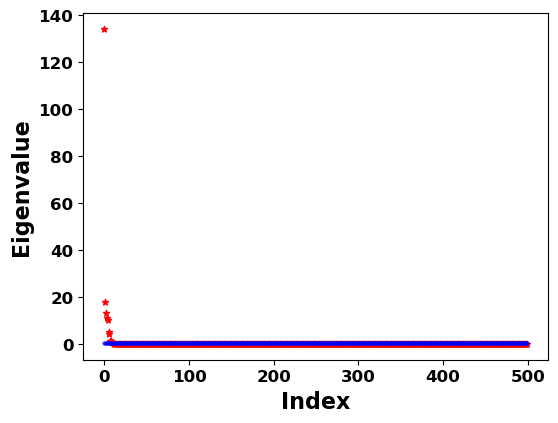

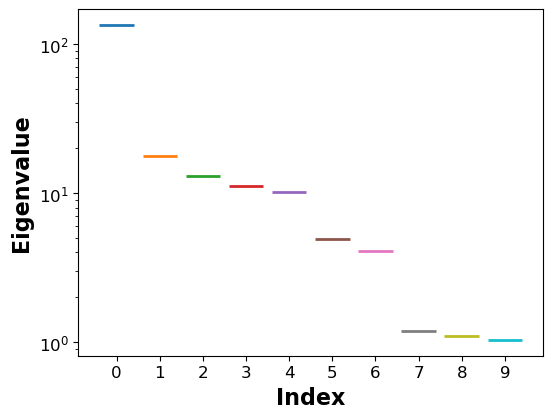

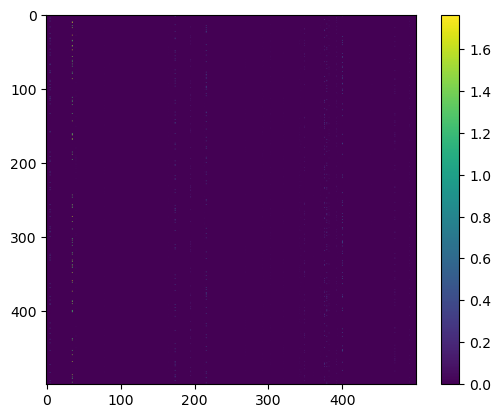

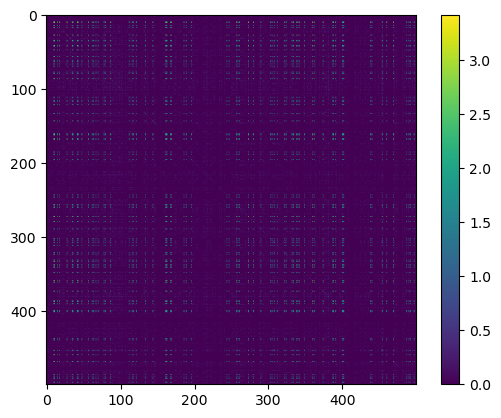

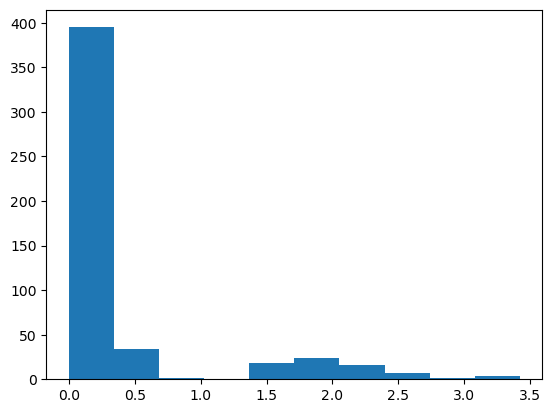

200.00049999999902


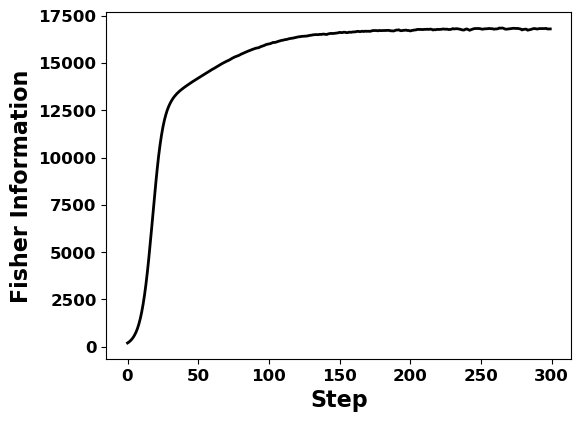

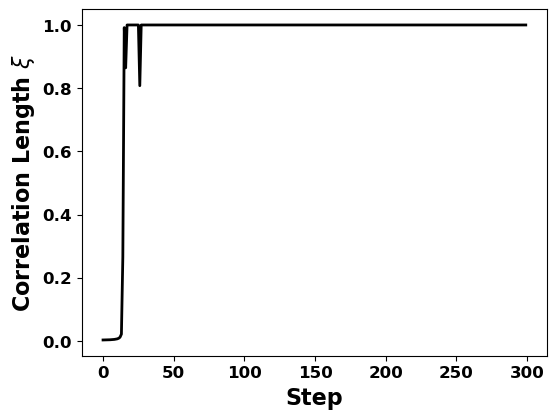

200.00059999999905 200.00059999999957


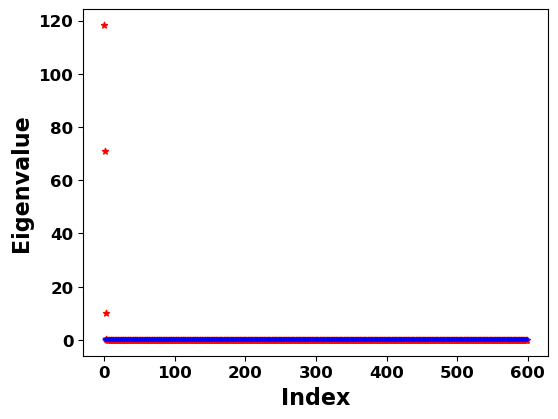

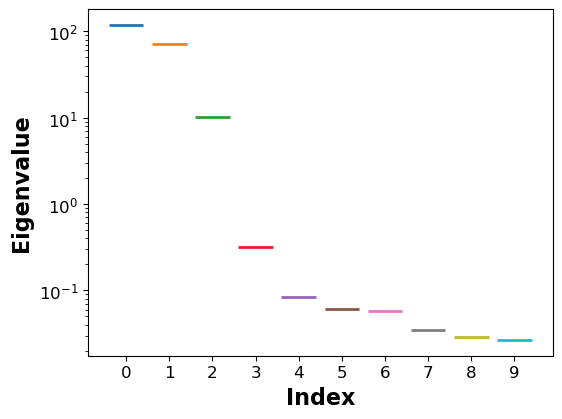

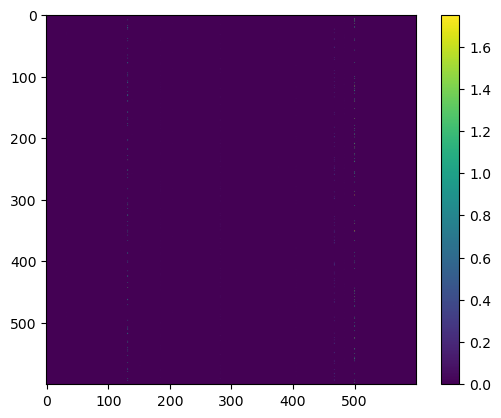

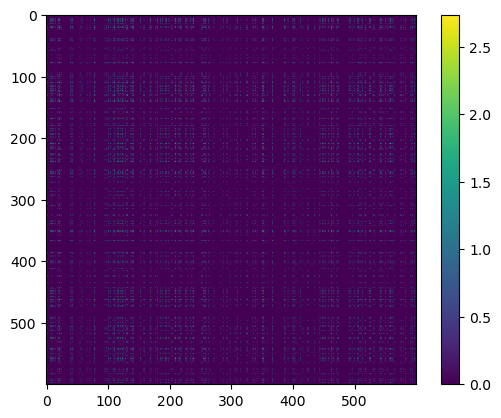

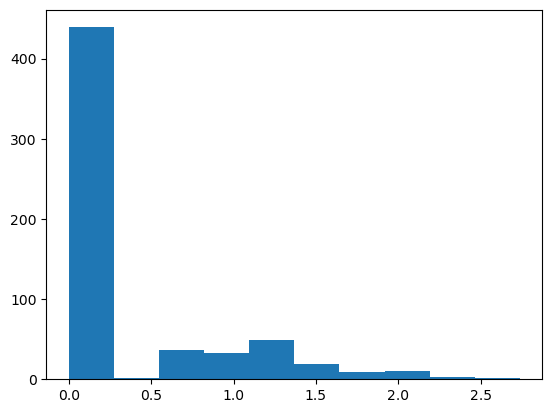

200.000599999999


In [7]:
A_arr=[]
W_arr=[]
Ai_arr=[]
Wi_arr=[]
for N in N_arr:
    f_prime = get_gradients(N, mode=modes[2])
    model=RobustHeterogeneousNetwork(N, topology=topo, avg_degree=N//10, alpha=H_weight, C=C, 
                 lambda_smooth=0.01, drop_prob=0.1)
    h_fisher, h_xi,h_xi_fft= [], [],[]
    for _ in range(300):
        W = model.get_effective_W()
        A =  W @ W.T + np.eye(N)*1e-6
        fi=f_prime.T @ A @ f_prime
        h_fisher.append(fi.item())
        
        h_xi.append(calculate_xi_field_theory(A, N))
        # h_xi_fft.append(calculate_xi_fourier_method(A, N))
                
        model.update_hebbian(f_prime, lr=0.001,penalty_strength=10)
    
    A_arr.append(A)
    W_arr.append(model.W)
    Ai_arr.append(model.A_init)
    Wi_arr.append(model.W_init)
    np.save(result_dir+'A'+str(N)+'_mat.npy',A)


    plt.figure(figsize=(6, 4.5))
    plt.plot(h_fisher,linewidth=2,color='black')
    plt.xticks(fontsize=12,fontweight='bold')
    plt.yticks(fontsize=12,fontweight='bold')
    plt.xlabel('Step', fontsize=16,fontweight='bold')
    plt.ylabel('Fisher Information', fontsize=16,fontweight='bold')
    plt.savefig(result_dir+str(N)+'_FI.png',bbox_inches='tight',dpi=300)
    plt.show()
    
    plt.figure(figsize=(6, 4.5))
    plt.plot(np.array(h_xi)/N,linewidth=2,color='black')
    plt.xticks(fontsize=12,fontweight='bold')
    plt.yticks(fontsize=12,fontweight='bold')
    plt.xlabel('Step', fontsize=16,fontweight='bold')
    plt.ylabel('Correlation Length $\\xi$', fontsize=16,fontweight='bold')
    plt.savefig(result_dir+str(N)+'_corr_length.png',bbox_inches='tight',dpi=300)
    plt.show()

    vals,_ =np.linalg.eigh(A)
    vals_init,_ =np.linalg.eigh(model.A_init)
    print(np.sum(vals),np.sum(vals_init))
    plt.figure(figsize=(6, 4.5))
    plt.scatter(np.arange(N),np.sort(vals)[::-1],s=20,marker='*',color='r')
    plt.scatter(np.arange(N),np.sort(vals_init)[::-1],s=5,color='b',alpha=0.5)
    plt.xlabel('Index', fontsize=16,fontweight='bold')
    plt.ylabel('Eigenvalue', fontsize=16,fontweight='bold')
    plt.xticks(fontsize=12,fontweight='bold')
    plt.yticks(fontsize=12,fontweight='bold')
    # plt.yscale('log')
    plt.savefig(result_dir+str(N)+'_eigen.png',bbox_inches='tight',dpi=300)
    plt.show()

    categories=np.arange(10)
    eigen_color=['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728', '#9467bd',
          '#8c564b', '#e377c2', '#7f7f7f', '#bcbd22', '#17becf']
    eigenvalues = {}
    for i in categories:
        eigenvalues[i] = np.sort(vals)[::-1][i]
    
    fig, ax = plt.subplots(figsize=(6, 4.5))
    
    for i, category in enumerate(categories):
        y = eigenvalues[category]
        x = np.full_like(y, i)
        ax.hlines(y, x - 0.4, x + 0.4,  lw=2, color = eigen_color[i])  # hlines 画横线
    
    ax.set_yscale('log')
    #ax.set_ylim(1e-7, 1e1)
    #ax.set_yticks([10**i for i in range(-2, 5)])
    #ax.set_yticklabels([f'\$10^{{{i}}}$' for i in range(-7, 2)])
    ax.set_xticks(range(len(categories)))
    ax.set_xticklabels(categories,fontsize=12)
    ax.tick_params(axis='y', labelsize=12)
    plt.xticks(rotation=0)
    
    ax.set_xlabel('Index', fontsize=16, fontweight='bold')
    ax.set_ylabel('Eigenvalue', fontsize=16, fontweight='bold')
    plt.savefig(result_dir+str(N)+'_log_eigen.png',bbox_inches='tight',dpi=300)
    
    plt.show()

    plt.imshow(model.W)
    plt.colorbar()
    plt.show()

    plt.imshow(A)
    plt.colorbar()
    plt.show()
    
    plt.hist(np.diag(A))
    plt.show()
    print(np.sum(np.diag(A)))

    
    # plt.imshow(model.A_init)
    # plt.colorbar()
    # plt.show()


In [8]:
def analyze_spectral_criticality(A_matrix, tol=1e-9):
    """
    Quantifies the criticality of a neural system using spectral methods.
    
    Args:
        A_matrix (np.ndarray): The NxN symmetric precision matrix (inverse covariance).
                               Represents the energy landscape curvature.
        tol (float): Threshold to treat eigenvalues as effectively zero.
        
    Returns:
        dict: Dictionary containing:
            - 'spectral_gap': The smallest non-zero eigenvalue (lambda_min).
            - 'correlation_length': Effective spatial range (xi).
            - 'ipr': Inverse Participation Ratio of the softest mode (Y).
            - 'is_critical': Boolean flag if system is near criticality.
    """
    # 1. Eigen-decomposition (using eigh for symmetric/Hermitian matrices)
    # eigenvalues are returned in ascending order
    evals, evecs = linalg.eigh(A_matrix)
    
    # 2. Identify the "Softest Mode" (Mass Term)
    # In a precision matrix, the smallest eigenvalue corresponds to the 
    # flattest direction in the energy landscape (highest variance).
    lambda_min = evals[0]
    
    # Handle numerical instability if lambda_min is practically zero (Goldstone mode)
    if lambda_min < tol:
        xi = np.inf
    else:
        # Formula: xi ~ 1 / sqrt(lambda_min)
        xi = 1.0 / np.sqrt(lambda_min)
        
    # 3. Compute Inverse Participation Ratio (IPR)
    # IPR quantifies the spatial extent of the eigenmode.
    # Y = sum(u_i^4) for normalized u.
    # If Y ~ 1/N -> Delocalized (Critical/Collective state).
    # If Y ~ 1   -> Localized (Single neuron state).
    
    u_soft = evecs[:, 0]  # Eigenvector corresponding to lambda_min
    
    # Ensure normalization (eigh usually returns normalized vectors, but good to be safe)
    u_soft = u_soft / np.linalg.norm(u_soft)
    
    ipr = np.sum(u_soft ** 4)
    
    return {
        "spectral_gap": lambda_min,
        "correlation_length": xi,
        "ipr": ipr,
        "regime": "Delocalized (Critical)" if ipr < (5.0 / len(A_matrix)) else "Localized",
        "soft_mode_vector": u_soft
    }

In [9]:
ipr_n=[]
for A in A_arr:
    results = analyze_spectral_criticality(A)
    
    print(f"Spectral Gap (Mass^2): {results['spectral_gap']:.4f}")
    print(f"Correlation Length:      {results['correlation_length']:.4f}")
    print(f"IPR (Localization):      {results['ipr']:.4f}")
    print(f"Regime:                  {results['regime']}")
    ipr_n.append(results['ipr'])

Spectral Gap (Mass^2): 0.0000
Correlation Length:      732.6434
IPR (Localization):      0.0293
Regime:                  Delocalized (Critical)
Spectral Gap (Mass^2): 0.0000
Correlation Length:      957.0273
IPR (Localization):      0.0179
Regime:                  Delocalized (Critical)
Spectral Gap (Mass^2): 0.0000
Correlation Length:      999.0979
IPR (Localization):      0.0095
Regime:                  Delocalized (Critical)
Spectral Gap (Mass^2): 0.0000
Correlation Length:      999.2236
IPR (Localization):      0.0083
Regime:                  Delocalized (Critical)
Spectral Gap (Mass^2): 0.0000
Correlation Length:      999.9700
IPR (Localization):      0.0059
Regime:                  Delocalized (Critical)
Spectral Gap (Mass^2): 0.0000
Correlation Length:      999.9517
IPR (Localization):      0.0051
Regime:                  Delocalized (Critical)


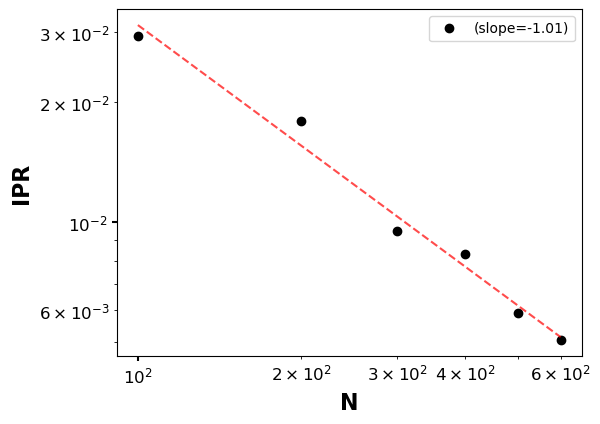

In [10]:

ipr_arr=np.array(ipr_n)
slope, intercept, r, p, std = linregress(np.log10(N_arr), np.log10(ipr_arr))


plt.rcParams['axes.labelweight'] = 'bold'
plt.rcParams['xtick.labelsize'] = 12
plt.rcParams['ytick.labelsize'] = 12
plt.rcParams['xtick.major.width'] = 1.5
plt.rcParams['ytick.major.width'] = 1.5

fig,ax=plt.subplots(figsize=(6, 4.5))
ax.loglog(N_arr, ipr_arr, 'o', color='black', label=f'(slope={slope:.2f})')
ax.loglog(N_arr, 10**intercept * N_arr**slope, '--', alpha=0.7,color='red')

plt.xlabel('N',fontsize=16,fontweight='bold')
plt.ylabel('IPR',fontsize=16,fontweight='bold')


plt.legend()
plt.savefig(result_dir+'IPR.png',bbox_inches='tight',dpi=300)
plt.show()

np.save(result_dir+'IPR.npy',ipr_arr)

In [11]:
# --- Analysis & Power Law Plotting ---
def plot_power_law(data, label, ax, title, num_bins=None):
    """
    Plot power law distribution with adaptive binning.
    
    Parameters:
    - data: array-like, the data to plot
    - label: str, label for the data
    - ax: matplotlib axis, axis to plot on
    - title: str, title for the plot
    - num_bins: int or None, if None uses adaptive binning based on data size
    """
    # Adaptive binning based on data size
    if num_bins is None:
        # Use Freedman-Diaconis rule for bin width selection
        n = len(data)
        if n > 1000:
            # For large datasets, use more bins
            num_bins = int(np.sqrt(n))
        else:
            # For smaller datasets, use fewer bins
            num_bins = max(10, int(n / 50))
    
    # Ensure we have at least 5 bins and at most 50 bins
    num_bins = max(5, min(50, num_bins))
    
    # Log-spaced bins
    bins = np.logspace(np.log10(max(min(data), 1e-10)),  # Avoid log(0)
                      np.log10(max(data)), 
                      num_bins + 1)
    
    # Calculate histogram
    counts, bins = np.histogram(data, bins=bins)
    x = (bins[:-1] + bins[1:]) / 2
    y = counts / np.diff(bins)  # Probability density
    
    # Remove zeros for log-log fit
    mask = (y > 0) & (x > 0)
    x_fit, y_fit = x[mask], y[mask]
    
    # Check if we have enough points for fitting
    if len(x_fit) < 3:
        ax.loglog(x, y, 'o', label=f'{label} (insufficient data for fit)')
        ax.set_title(title)
        ax.set_xlabel('Value')
        ax.set_ylabel('Probability Density')
        ax.legend()
        return
    
    # Fit: log(y) = -tau * log(x) + C
    slope, intercept, r_value, p_value, std_err = linregress(np.log10(x_fit), np.log10(y_fit))
    
    # Plot data and fit
    ax.loglog(x, y, 'o', markersize=8, color='cyan',alpha=0.7, label=f'{label}')
    ax.loglog(x_fit, 10**intercept * x_fit**slope, '--', alpha=0.8, 
              linewidth=2,color='black', label=f'Fit: slope={slope:.2f}')
    
    # Add R² value if correlation is high
    if abs(r_value) > 0.8:
        ax.text(0.05, 0.95, f'R² = {r_value**2:.3f}', 
                transform=ax.transAxes, fontsize=9,
                verticalalignment='top')
    
    # ax.set_title(title)
    ax.set_xlabel(label,fontsize=16, fontweight='bold')
    ax.set_ylabel('Probability Density',fontsize=16, fontweight='bold')
    ax.legend(fontsize=14)
    ax.grid(True, alpha=0.3, which='both')

Max Eigenvalue: 0.99900
IPR: 0.2487 (Theoretical Min for N=600 is 0.0017)


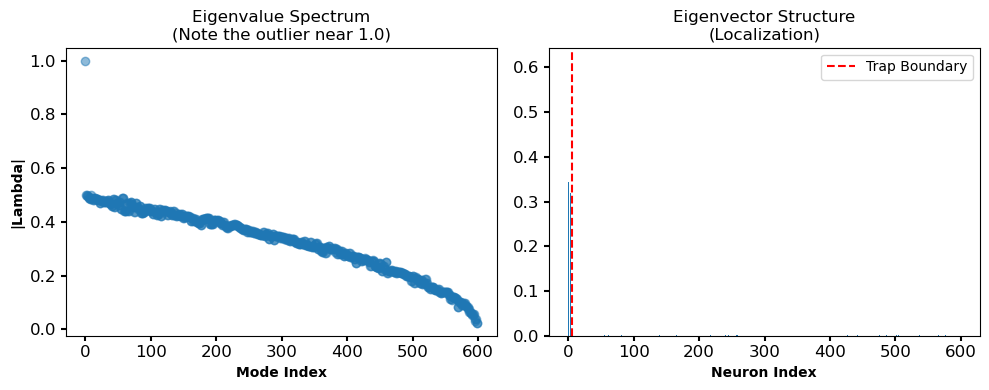

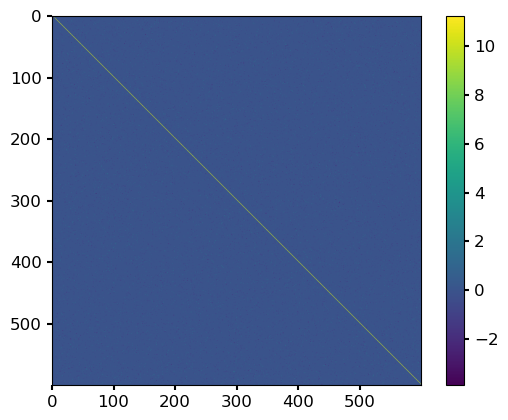

In [12]:
def construct_localized_matrix(N=100, trap_size=10, dt=0.1):
    """
    Constructs a weight matrix W = I - dt*A that is critical but localized.
    Strategy: Embed a critical 'clique' into a sub-critical bulk.
    
    Args:
        N: Total neurons
        trap_size: Size of the localized group
    Returns:
        W: Propagator matrix (for simulation)
        A: Effective interaction matrix (A = (I - W)/dt)
    """
    # 1. Create the Bulk (Sub-critical Background)
    # A sparse random matrix with low spectral radius
    M = np.random.randn(N, N) * 0.1
    # Make it sparse
    mask = np.random.rand(N, N) > 0.9
    M = M * mask
    
    # Normalize Bulk to be "Dead" (e.g., lambda=0.5)
    rho_bulk = np.max(np.abs(np.linalg.eigvals(M)))
    M = M / rho_bulk * 0.5
    
    # 2. Create the Trap (The Localized Critical Mode)
    # A dense block for the first 'trap_size' neurons
    trap_block = np.random.rand(trap_size, trap_size)
    # Normalize Trap to be Critical (lambda=0.999)
    rho_trap = np.max(np.abs(np.linalg.eigvals(trap_block)))
    trap_block = trap_block / rho_trap * 0.999
    
    # 3. Embed Trap into W
    # We replace the top-left block with the trap
    M[:trap_size, :trap_size] = trap_block
    
    # Optional: Add tiny leakage from trap to bulk to prove connectivity isn't strictly zero
    # (Physics: Anderson Localization allows for weak tunneling, but effectively trapped)
    M[:trap_size, trap_size:] *= 0.01 
    M[trap_size:, :trap_size] *= 0.01
    
    # 4. Back-calculate A (for your physics formulation)
    # W = I - dt*A  =>  dt*A = I - W  => A = (I - W) / dt
    A = (np.eye(N) - M) / dt
    
    return M, A

# --- Verification Routine ---
def verify_localization(M, trap_size):
    evals, evecs = np.linalg.eig(M)
    
    # Find the leading eigenmode (closest to 1 or max magnitude)
    idx = np.argmax(np.abs(evals))
    lambda_max = np.abs(evals[idx])
    v_max = np.abs(evecs[:, idx])
    
    # Calculate IPR
    v_norm = v_max / np.linalg.norm(v_max)
    ipr = np.sum(v_norm**4)
    
    print(f"Max Eigenvalue: {lambda_max:.5f}")
    print(f"IPR: {ipr:.4f} (Theoretical Min for N={len(W)} is {1/len(W):.4f})")
    
    # Plot
    plt.figure(figsize=(10, 4))
    plt.subplot(1, 2, 1)
    plt.plot(np.abs(evals), 'o', alpha=0.5)
    plt.title("Eigenvalue Spectrum\n(Note the outlier near 1.0)")
    plt.xlabel("Mode Index")
    plt.ylabel("|Lambda|")
    
    plt.subplot(1, 2, 2)
    plt.bar(range(len(v_max)), v_norm)
    plt.axvline(trap_size, color='r', linestyle='--', label='Trap Boundary')
    plt.title("Eigenvector Structure\n(Localization)")
    plt.xlabel("Neuron Index")
    plt.legend()
    
    plt.tight_layout()
    plt.show()

# Execute
M_loc, A_loc = construct_localized_matrix(N=N, trap_size=5)
verify_localization(M_loc, trap_size=5)

plt.imshow(A_loc)
plt.colorbar()
plt.show()

In [13]:
A_shuffled = A.copy()

# 提取非对角线索引
mask_off_diag = ~np.eye(N, dtype=bool)
off_diag_values = A_shuffled[mask_off_diag]

# 打乱
np.random.shuffle(off_diag_values)

# 填回
A_shuffled[mask_off_diag] = off_diag_values

In [14]:
from scipy.integrate import trapz
def simulate_quench_avalanche(A, N, num_quenches=1000):
    """
    模拟 Quench 动力学中的雪崩 (Response Avalanche)。
    核心逻辑：统计对于微小的参数变化 delta_A，系统状态变化 delta_x 的分布。
    """

    
    # 2. 初始化系统状态
    # 我们需要一个非零的“外场”或“输入” y，使得 x 有非零的平衡位置
    # Ax = y  => x = A^-1 y
    y = 0.1*np.random.randn(N)
    x_current = np.linalg.solve(A, y)
    
    avalanche_sizes = []
    # durations=[]

    # # 时间轴 (用于积分)
    # t_eval = np.logspace(1, 10, 2000) # 覆盖快慢尺度
    
    # 3. 循环执行 Quench 实验
    for _ in range(num_quenches):
        # y = 0.1*np.random.randn(N)
        # x_current = np.linalg.solve(A, y)

        
        # --- A. 施加微扰 (The Quench) ---
        # 这种扰动模拟突触权重的微小漂移或学习更新
        # 强度必须很小，否则系统会彻底崩溃



        
        perturbation_strength = 1e-6
        R = np.random.randn(N, N)
        delta_A = perturbation_strength * (R + R.T) # 对称扰动
        
        # --- B. 计算新的平衡态 ---
        A_new = A + delta_A
        
        # 检查正定性 (可选，防止数值爆炸)
        # 在微小扰动下，Sloppy 系统的软模极易变负，这里简单处理：
        # 如果奇异，则跳过统计（或视为无穷大雪崩）


        x_new = np.linalg.solve(A_new, y)
            
        # --- C. 提取雪崩规模 (Avalanche Size) ---
        # 定义：状态向量在相空间中的位移距离
        dx = x_new - x_current
        size = np.linalg.norm(dx)
        
        avalanche_sizes.append(size)

        # # #-----------------------------------
        # # # 谱分解 (用于预测)
        # evals, evecs = np.linalg.eigh(A_new)
        # evals = np.clip(evals, 1e-9, None) # 稳定性修正
        # x_new_proj = (evecs.T @ y) / evals
        # x_old_proj = evecs.T @ x_current
        
        # # 模态激发系数 c_k (在特征基下的位移分量)
        # coeffs = x_new_proj - x_old_proj

        # # --- 1. 重构速度曲线 v(t) ---
        # # v(t) = || sum( -lambda_k * c_k * exp(-L_k * t) * v_k ) ||
        # #      = sqrt( sum( (-lambda_k * c_k * exp(-L_k * t))^2 ) )
        
        # # 使用广播机制计算所有时刻的速度
        # # decay_matrix: [N_modes, N_time]
        # decay_terms = (coeffs * evals)[:, None] * np.exp(-evals[:, None] * t_eval[None, :])
        # # 速度 v(t)
        # v_t = np.sqrt(np.sum(decay_terms**2, axis=0))

        # # 总位移 (用于归一化)
        # total_displacement = trapz(v_t, t_eval)
        # if total_displacement < 1e-9: continue
        
        # # --- Method 1: Threshold Time (1% of Peak Speed or Residual) ---
        # # 简单起见，看速度衰减到峰值的 1%
        # peak_v = np.max(v_t)
        # threshold = 0.01 * peak_v
        # # 找最后一个大于阈值的时刻
        # active_idx = np.where(v_t > threshold)[0]
        # if len(active_idx) > 0:
        #     T_threshold = t_eval[active_idx[-1]]
        # else:
        #     T_threshold = 0
            
        # # --- Method 2: Integral Time Scale (Time Centroid) ---
        # # T_int = Integral(t * v(t)) / Integral(v(t))
        # numerator = trapz(t_eval * v_t, t_eval)
        # T_integral = numerator / total_displacement

        # durations.append(T_threshold)

        


        # --- D. 更新系统 ---
        # 让系统演化下去 (Cumulative Aging) 
        # 或者重置 A (Independent Samples)
        # 这里选择 Cumulative，模拟真实系统的连续演化
        A = A_new 
        x_current = x_new

        
        # try:
        #     x_new = np.linalg.solve(A_new, y)
            
        #     # --- C. 提取雪崩规模 (Avalanche Size) ---
        #     # 定义：状态向量在相空间中的位移距离
        #     dx = x_new - x_current
        #     size = np.linalg.norm(dx)
            
        #     avalanche_sizes.append(size)

        #     # --- D. 更新系统 ---
        #     # 让系统演化下去 (Cumulative Aging) 
        #     # 或者重置 A (Independent Samples)
        #     # 这里选择 Cumulative，模拟真实系统的连续演化
        #     A = A_new 
        #     x_current = x_new

        # except np.linalg.LinAlgError:
        #     # 矩阵奇异，意味着特征值触底 0，发生了灾难性雪崩
        #     pass
        

    return np.array(avalanche_sizes)

# --- 运行 ---
sizes = simulate_quench_avalanche(A,model.N)


fig,ax=plt.subplots(figsize=(6, 4.5))
plot_power_law(sizes, r'$||\mathbf{dx}||$', ax, "Avalanche Size Distribution")
plt.savefig(result_dir+'dx_powerlaw.png',bbox_inches='tight',dpi=300)

ImportError: cannot import name 'trapz' from 'scipy.integrate' (/home/linux/miniforge3/envs/NEURON/lib/python3.14/site-packages/scipy/integrate/__init__.py)

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.fft import fft, ifft

def analyze_soft_manifold_dynamics(A_learned, keep_ratio=0.1, steps=100000):
    """
    1. Decompose A into eigenmodes.
    2. Keep only the bottom k% (Soft Modes).
    3. Simulate Langevin dynamics on this Flat Manifold.
    4. Reconstruct A_soft (The effective interaction matrix).
    5. Analyze ACF and Distribution.
    """
    N = A_learned.shape[0]
    
    # --- Step 1: Spectral Decomposition ---
    evals, evecs = np.linalg.eigh(A_learned)
    
    # Sort (Smallest eigenvalues first)
    idx = np.argsort(evals)
    evals = evals[idx]
    evecs = evecs[:, idx]
    
    # --- Step 2: Spectral Surgery (The Filtering) ---
    num_keep = max(1, int(N * keep_ratio))
    lambda_soft = evals[:num_keep]
    V_soft = evecs[:, :num_keep]
    
    print(f"=== Spectral Surgery ===")
    print(f"Total Modes: {N} -> Kept Soft Modes: {num_keep}")
    print(f"Eigenvalue Range (Kept): [{lambda_soft[0]:.2e}, {lambda_soft[-1]:.2e}]")
    
    # Reconstruct A_soft (Effective Connectivity on the Manifold)
    # A_soft = V * Lambda * V^T
    # 这代表了去除了高频刚性约束后的“有效相互作用”
    A_soft = V_soft @ np.diag(lambda_soft) @ V_soft.T
    
    # --- Step 3: Simulation in Mode Space (Efficient) ---
    # Instead of simulating x, we simulate the mode coefficients y
    # dy/dt = -lambda * y + noise
    
    dt = 0.1
    # 临界慢化关键：衰减系数极度接近 1
    decay = np.exp(-lambda_soft * dt) 
    noise_scale = 0.1
    
    y = np.zeros(num_keep)
    activity_trace = []
    
    # Warmup
    for _ in range(1000):
        y = y * decay + np.random.randn(num_keep) * noise_scale
        
    # Recording Loop
    print("Simulating Dynamics...")
    for t in range(steps):
        # Langevin Update
        y = y * decay + np.random.randn(num_keep) * noise_scale
        
        # Projection back to Neuron Space (Observable)
        # x(t) = Sum y_k * v_k
        # We only calculate the global magnitude to save time
        x_state = V_soft @ y
        
        # Macro Observable: Total Magnetization / Activity
        # 取绝对值总和或平方和
        M_t = np.mean(np.abs(x_state))
        activity_trace.append(M_t)
        
    activity_trace = np.array(activity_trace)
    
    # --- Step 4: Analysis ---
    
    # A. Autocorrelation Function (ACF) via FFT
    # ACF(tau) = <x(t)x(t+tau)>
    # 使用 FFT 计算加速
    n = len(activity_trace)
    f = fft(activity_trace - np.mean(activity_trace))
    acf = np.real(ifft(f * np.conj(f)))
    acf = acf[:n//2] / acf[0] # Normalize
    
    # B. Distribution (PDF)
    # 使用对数分箱 (Log-Binning) 以在 Log-Log 图上获得平滑曲线
    bins = np.logspace(np.log10(min(activity_trace[activity_trace>0])), 
                       np.log10(max(activity_trace)), 50)
    hist, bin_edges = np.histogram(activity_trace, bins=bins, density=True)
    bin_centers = (bin_edges[:-1] + bin_edges[1:]) / 2
    
    # --- Step 5: Visualization ---
    fig, axes = plt.subplots(1, 3, figsize=(20, 5))
    
    # Plot 1: Time Series (Trace)
    axes[0].plot(activity_trace[:2000], lw=0.8, color='#333')
    axes[0].set_title("Activity Trace (First 2000 steps)")
    axes[0].set_xlabel("Time")
    axes[0].set_ylabel("|x(t)|")
    axes[0].grid(alpha=0.3)
    
    # Plot 2: ACF (Log-Log) -> Look for Power Law
    lags = np.arange(len(acf))
    axes[1].loglog(lags[1:], acf[1:], lw=2, color='crimson', label='Simulation')
    # Reference Slope -0.5 (Example)
    # axes[1].plot(lags[10:1000], 10*lags[10:1000]**(-0.5), 'k--', alpha=0.5, label='Slope -0.5')
    axes[1].set_title("Autocorrelation Function (ACF)")
    axes[1].set_xlabel("Time Lag (tau)")
    axes[1].set_ylabel("C(tau)")
    axes[1].legend()
    axes[1].grid(alpha=0.3, which='both')
    
    # Plot 3: PDF (Log-Log) -> Look for Power Law
    axes[2].loglog(bin_centers, hist, 'o-', markersize=4, color='royalblue', label='Data')
    axes[2].set_title("Activity Distribution P(x)")
    axes[2].set_xlabel("Activity Size x")
    axes[2].set_ylabel("Probability Density")
    axes[2].grid(alpha=0.3, which='both')
    
    plt.tight_layout()
    plt.show()
    
    return A_soft, activity_trace, acf

# 使用示例 (假设 A_learned 已经存在)
A_soft, trace, acf = analyze_soft_manifold_dynamics(A, keep_ratio=0.99)

